# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. So basically, without a penalty, the model will try to fit the data as closely as possible, even if that means overfitting.When you add a penalty that grows with the size of the coefficients, you're forcing the model to not make coefficients too large.
2. Regularization gives you control through the alpha value. if alpha is too cmall then the model fits closely to the data and there is low bias with high variance. If lpha value is too large then the model is more restricted and there is a higehr bias with lower variance.
3. Ridge uses squared coefficients while LASSO uses absolute values. The main differences is that Ridge shrinks coefficients but keeps variables while LASSO can shrink sone coefficeitns all the way to zero.
4. You standardize varibales through: (x-mean)/standard deviation. This is because regularization depends on the coefficent size and if variables are on different scales, the penalty will not be applied fairly. So scalin variables allows for them to be treated equally.
5. The alpha value is typically selected through cross-validation wherre we try different alpha values, compute validation error and pick the one that gives the lowest error.
6. No we do not include the penalty term because the penalty is just for training to control the model.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [1]:
! git clone https://github.com/smerashanmugan/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (11/11), done.
Receiving objects: 100% (43/43), 122.17 KiB | 2.39 MiB/s, done.
remote: Total 43 (delta 13), reused 6 (delta 6), pack-reused 26 (from 2)
Resolving deltas: 100% (14/14), done.
Download complete
Extracting data files...
Data extracted


In [14]:
import pandas as pd

df = pd.read_csv('./data/cars_hw.csv')
df['Age'] = 2024 - df['Make_Year']
X = df[['Mileage_Run','Age']]
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [15]:
from sklearn.linear_model import LinearRegression

y = df['Price']
model = LinearRegression()
model.fit(X_scaled, y)
feature_names = poly.get_feature_names_out(['Mileage_Run','Age'])
interaction_idx = list(feature_names).index('Mileage_Run Age')
interaction_coef = model.coef_[interaction_idx]
interaction_coef

np.float64(-1251592.3408260453)

2. the sign is negative

In [16]:
from sklearn.linear_model import LassoCV
import numpy as np

alphas = np.logspace(1, 3, 20)
lasso = LassoCV(alphas=alphas, cv=20)
lasso.fit(X_scaled, y)
lasso.alpha_

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 13229914430.28125, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 131934043992.82812, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 298840628722.28125, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Obje

np.float64(233.57214690901213)

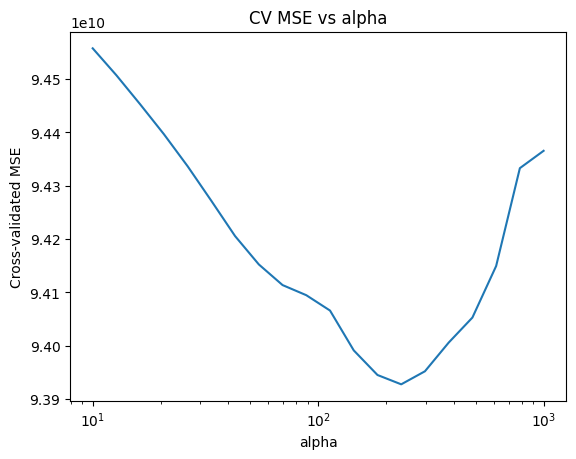

In [17]:
import matplotlib.pyplot as plt
import numpy as np

mse_mean = lasso.mse_path_.mean(axis=1)
plt.plot(lasso.alphas_, mse_mean)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('CV MSE vs alpha')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 185708452846.75, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1496502935991.375, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1062651595526.5, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective 

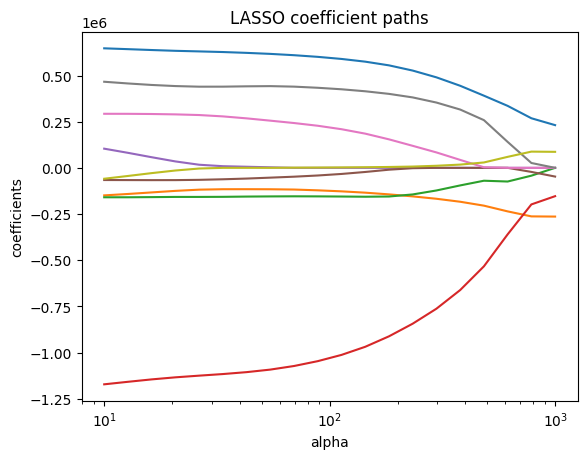

In [18]:
from sklearn.linear_model import lasso_path
import matplotlib.pyplot as plt

alphas_lasso, coefs, _ = lasso_path(X_scaled, y, alphas=alphas)
for i in range(coefs.shape[0]):plt.plot(alphas_lasso, coefs[i])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('coefficients')
plt.title('LASSO coefficient paths')
plt.show()

6. Only a few features are actually selected, mainly the main effects (Mileage_Run and Age) and possibly one interaction term. Most of the higher-order polynomial terms shrink to zero. Out of the total features, around 60–70% of the coefficients are set equal to zero.

7. The LASSO coefficients are generally smaller in magnitude compared to the linear regression coefficients because of the penalty. No coefficients increase in magnitude after regularization. Some coefficients can change sign, especially smaller or less important features, as LASSO shrinks and rebalances the model.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [19]:
import pandas as pd

df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
num_vars = ['age','ejection_fraction','serum_creatinine']
X_num = df[num_vars]
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
poly = PolynomialFeatures(degree=3, include_bias=False)
X_num_poly = poly.fit_transform(X_num)
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num_poly)
cat_vars = ['anaemia','diabetes','high_blood_pressure','smoking']
X_cat = df[cat_vars]
poly_int = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat_int = poly_int.fit_transform(X_cat)
import numpy as np
X_final = np.hstack([X_num_scaled, X_cat_int])

In [20]:
from sklearn.linear_model import LinearRegression

y = df['DEATH_EVENT']
model = LinearRegression()
model.fit(X_final, y)
coefs = model.coef_
coefs

array([ 1.53915561, -2.19249366, -0.85358815, -3.67865393, -0.60091803,
        1.84156257,  3.43097646,  2.67339362, -2.64704061,  1.99313494,
        0.90802595, -0.69752151, -0.08120632, -1.57766526,  1.28409929,
       -1.25034105, -1.27004314,  1.17947493,  0.07215578,  0.00809253,
       -0.0707051 , -0.00793437, -0.10268659,  0.02615948, -0.02725057,
        0.06490812,  0.13244293,  0.15607823,  0.10145536])

2. Some coefficients show unexpected signs, like the same variable having both positive and negative values across different terms. This happens because once we include higher order powers and interactions, the effect of each variable is split across multiple terms instead of just one coefficient.So even if individual coefficients look inconsistent, together they capture the overall relationship more accurately.

In [21]:
from sklearn.linear_model import LassoCV
import numpy as np

alphas = np.logspace(-5, 5, 30)
lasso = LassoCV(alphas=alphas, cv=20)
lasso.fit(X_final, y)
lasso.alpha_

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.307020115418851, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.28938187158509265, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5.078673023930669, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Con

np.float64(0.005736152510448681)

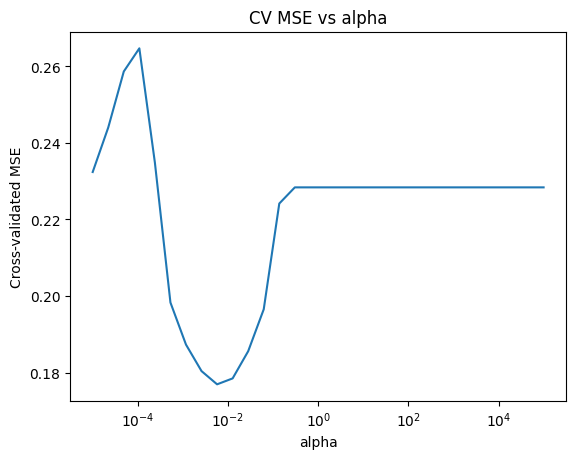

In [22]:
import matplotlib.pyplot as plt

mse_mean = lasso.mse_path_.mean(axis=1)
plt.plot(lasso.alphas_, mse_mean)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('CV MSE vs alpha')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.1335358515879932, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.012804029935630012, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5.358315720381807, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: C

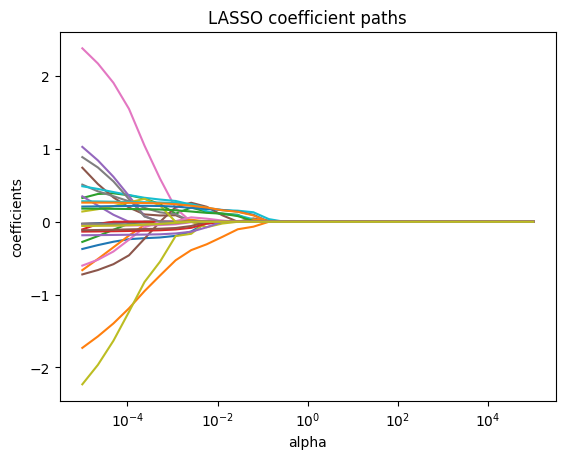

In [23]:
from sklearn.linear_model import lasso_path
import matplotlib.pyplot as plt

alphas_lasso, coefs, _ = lasso_path(X_final, y, alphas=alphas)
for i in range(coefs.shape[0]):plt.plot(alphas_lasso, coefs[i])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('coefficients')
plt.title('LASSO coefficient paths')
plt.show()

6. Only a few features are selected, and most of the coefficients go to zero. Around 70–80% are set equal to zero.Compared to linear regression, the LASSO coefficients are smaller, and many are removed completely. No coefficients increase in magnitude, but some do change sign. The LASSO signs make more sense because the model is simpler and less noisy. It avoids overfitting, so the results are more stable.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

1. The objective function is the mean squared error plus the ridge penalty term.

2. Start with the objective function, which is the average squared error plus the penalty on b1. Take the derivative with respect to b0 and set it equal to zero. Since the data is mean-centered, this gives b0 = 0. Then take the derivative with respect to b1 and set it equal to zero. Solve for b1, and you get(x_tilde means each value of x and subtract the average of x): b1 = (sum of x_tilde times y_tilde) divided by (sum of x_tilde squared plus n times alpha). So the final answers are:
b0 = 0
b1 = (sum x_tilde y_tilde) / (sum x_tilde squared + n alpha)

3. As alpha increases, the denominator gets larger, so the value of b1 becomes smaller.
So increasing alpha shrinks the slope coefficient toward zero.
This means the model becomes less sensitive to changes in x and more simple.

4. The main challenge is that the absolute value b1 is not differentiable at 0, so you can’t just take derivatives the same way as before. Because of this, you don’t always get a smooth solution like ridge.
For LASSO, it becomes ideal to set b1=0 when the relationship between x and y is not strong enough to overcome the penalty.